<a href="https://colab.research.google.com/github/voronv27/Lab1/blob/main/03_rnn_and_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
# set random seed
import os, random
import numpy as np
import torch
def seed_everything(seed: int = 42):
 random.seed(seed)
 np.random.seed(seed)
 os.environ["PYTHONHASHSEED"] = str(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 torch.backends.cudnn.benchmark = False
 torch.backends.cudnn.deterministic = True

seed_everything(42)
rng = np.random.default_rng(42)

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# load data as torch tensor
files = ['body_acc_x_train.txt',
         'body_acc_y_train.txt',
         'body_acc_z_train.txt',
         'body_gyro_x_train.txt',
         'body_gyro_y_train.txt',
         'body_gyro_z_train.txt',
         'total_acc_x_train.txt',
         'total_acc_y_train.txt',
         'total_acc_z_train.txt' ]

# data will be in shape (C, N, T)
x = []
for file in files:
    x.append(torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/Inertial_Signals/' + file)))

# convert to (N, C, T)
x = torch.stack(x).permute(1, 0, 2) #rearranged so datapoints are 128 time steps with 9 features

y = torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/y_train.txt'))

print(x.shape)
print(y.shape)

torch.Size([7352, 9, 128])
torch.Size([7352])


In [65]:
from sklearn.model_selection import train_test_split
import torch.nn.functional as F


X_train, X_val, Y_train, Y_val = train_test_split(x, y, random_state = 67, test_size=0.3)

X_test, X_dev, Y_test, Y_dev = train_test_split(X_val, Y_val,
                                                random_state = 67,
                                                test_size=0.5)

Y_train = F.one_hot(Y_train.long()- 1, num_classes=6).float()
Y_test = F.one_hot(Y_test.long()- 1, num_classes=6).float()
Y_dev = F.one_hot(Y_dev.long()- 1, num_classes=6).float()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)
X_dev = torch.tensor(X_dev, dtype=torch.float32).to(device)
Y_dev = torch.tensor(Y_dev, dtype=torch.float32).to(device)


print(X_train.shape)

torch.Size([5146, 9, 128])


/tmp/ipykernel_9895/924158746.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
/tmp/ipykernel_9895/924158746.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
/tmp/ipykernel_9895/924158746.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
/tmp/ipykernel_9895/924158746.py:21: UserWarning: To copy construct from a tensor, it is recommended to u

In [66]:
import matplotlib.pyplot as plt

def plot_dev_train_loss(dev_loss, train_loss, title = ""):
  plt.plot(train_loss, label='train')
  plt.plot(dev_loss, label='dev')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(title)
  plt.legend()
  plt.show()

In [67]:
from torch import nn
import torch

class LSTMNetwork(nn.Module):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.CrossEntropyLoss):
    super().__init__()
    self.hidden_size = n_hidden

    self.rnn = nn.LSTM(input_size=n_features,
                      hidden_size=n_hidden,
                      num_layers=1,
                      batch_first=True)

    self.fc = nn.Linear(n_hidden, n_output)
    self.loss_function = loss_function()
    self.output_activation = nn.Softmax(dim=1)

    self.optimizer = torch.optim.AdamW(self.parameters(), lr=0.01, weight_decay=0.001)


  def forward(self, x):
    rnn_out, h_n = self.rnn(x)

    last_output = rnn_out[:, -1, :]
    output = self.fc(last_output)

    return output

  def train_step(self, X, y):
    self.train()

    #forward propagation
    pred = self(X)
    loss = self.loss_function(pred, y)

    #back propagation
    loss.backward()
    self.optimizer.step()
    self.optimizer.zero_grad()

    return loss

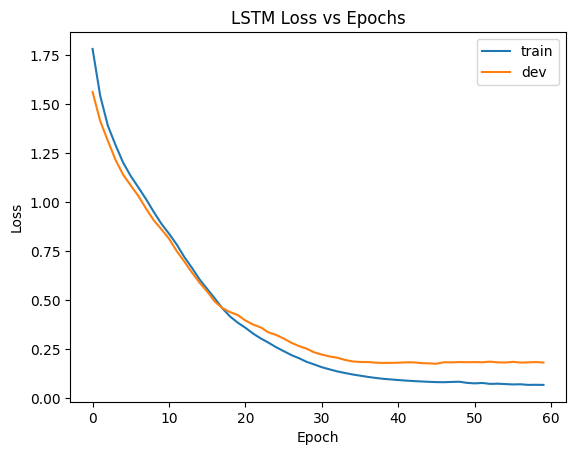



Test loss: 0.1656801998615265


Test accuracy: 0.9329102447869447


In [92]:
from sklearn.metrics import accuracy_score

n_hidden = 128
n_features = X_train.shape[2]
n_output = 6
epochs = 60

LSTM_model = LSTMNetwork(n_features, n_hidden, n_output)
LSTM_model.to(device)

train_losses = list()
dev_losses = list()

for t in range(epochs):
  loss = LSTM_model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  LSTM_model.eval()
  with torch.no_grad():
    pred = LSTM_model(X_dev)
    dev_loss = LSTM_model.loss_function(pred, Y_dev)
    dev_losses.append(dev_loss.item())

plot_dev_train_loss(dev_losses, train_losses, "LSTM Loss vs Epochs")

Y_pred = LSTM_model(X_test)
test_loss = LSTM_model.loss_function(Y_pred, Y_test)
print("\n\nTest loss:", test_loss.item())
accuracy = accuracy_score(Y_test.argmax(dim=-1), Y_pred.argmax(dim=-1))
print("\n\nTest accuracy:", accuracy)

In [93]:
from torch.optim import lr_scheduler

class RobustLSTM(LSTMNetwork):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.CrossEntropyLoss):
    super().__init__(n_features, n_hidden, n_output, loss_function)
    self.scheduler = lr_scheduler.StepLR(self.optimizer, step_size=30, gamma=0.1)

  def train_step(self, X, y):
    self.train()

    # forward propagation
    pred = self(X)
    loss = self.loss_function(pred, y)

    # back propagation
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    # adding gradient clipping

    self.optimizer.step()
    self.optimizer.zero_grad()

    self.scheduler.step()

    return loss


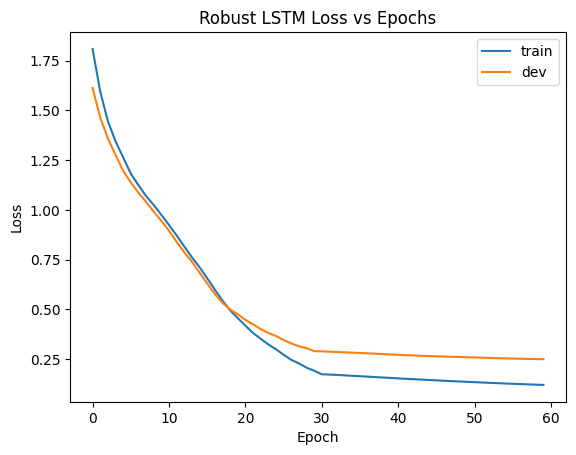



Test loss: 0.22915321588516235


Test accuracy: 0.914777878513146


In [94]:
robust_model = RobustLSTM(n_features, n_hidden, n_output)
robust_model.to(device)

train_losses = list()
dev_losses = list()

for t in range(epochs):
  loss = robust_model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  robust_model.eval()
  with torch.no_grad():
    pred = robust_model(X_dev)
    dev_loss = robust_model.loss_function(pred, Y_dev)
    dev_losses.append(dev_loss.item())

plot_dev_train_loss(dev_losses, train_losses, "Robust LSTM Loss vs Epochs")

Y_pred = robust_model(X_test)
test_loss = robust_model.loss_function(Y_pred, Y_test)
print("\n\nTest loss:", test_loss.item())
accuracy = accuracy_score(Y_test.argmax(dim=-1), Y_pred.argmax(dim=-1))
print("\n\nTest accuracy:", accuracy)

1 WALKING

2 WALKING_UPSTAIRS

3 WALKING_DOWNSTAIRS

4 SITTING

5 STANDING

6 LAYING

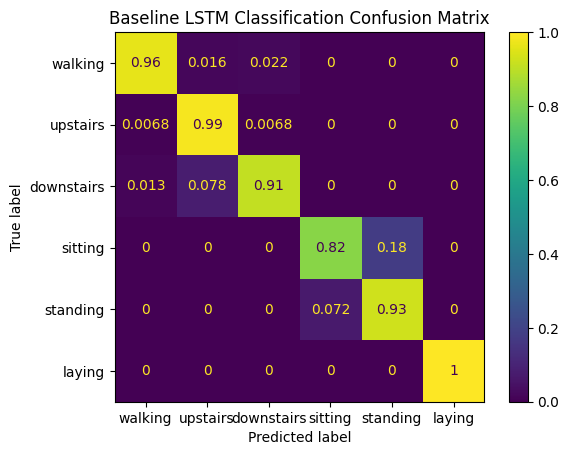

<Figure size 640x480 with 0 Axes>

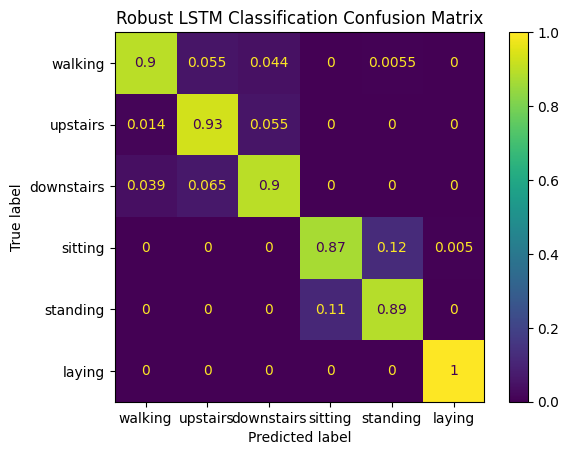

<Figure size 640x480 with 0 Axes>

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
  y_true_categorical = np.argmax(y_true, axis=1)
  y_pred_categorical = np.argmax(y_pred, axis=1)

  display_labels = ["walking", "upstairs", "downstairs",\
                    "sitting", "standing", "laying"]
  cm = confusion_matrix(y_true_categorical, y_pred_categorical)

  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                      display_labels=display_labels)
  cm_display.plot()
  plt.title(title)
  plt.show()
  plt.clf()


LSTM_y_pred = LSTM_model(X_test)
plot_confusion_matrix(Y_test.cpu().detach().numpy(),
                      LSTM_y_pred.cpu().detach().numpy(),
                      "Baseline LSTM Classification Confusion Matrix")

Robust_y_pred = robust_model(X_test)
plot_confusion_matrix(Y_test.cpu().detach().numpy(),
                      Robust_y_pred.cpu().detach().numpy(),
                      "Robust LSTM Classification Confusion Matrix")

Between the two models, standing and sitting were most commonly confused for one another. This makes sense, as the gyroscopic profile of sitting and standing are the two most similar, both being stationary activities where the instrument is in a similar position. For similar reasons, the moving classes were all occasionally confused with one another. However, the overall performance of both models was strong, though the baseline outperformed the modified LSTM over and in every class except for sitting prediction. This may be a product of overpenalizing regularization. It may be worth it in the future to allow tweaks to weight decay for the "robust" model class.